<a href="https://colab.research.google.com/github/SamyuthaPodamala/ATM-Interface-using-python/blob/main/Visual_Text_Extraction_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pytesseract

In [2]:
import cv2

In [3]:
!pip install utils


  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13905 sha256=212a3067f69068dd2ca282c7b2940d5fa1e4d70040c770f1fb3438fd254e5c85
  Stored in directory: /root/.cache/pip/wheels/b8/39/f5/9d0ca31dba85773ececf0a7f5469f18810e1c8a8ed9da28ca7
Successfully built utils


In [4]:
import sys

def good(message:str):
	''' Prints a message with [+] at the front to signify success '''
	print("[+] " + str(message))

def bad(message:str):
	''' Prints a message with [-] at the front to signify failure '''
	print("[-] " + str(message))
def info(message:str):
	''' Prints a message to signify information '''
	print("[ ] " + str(message))

def fatal(failure:str):
	print("[/] " + str(failure) + " failed, exiting now")
	sys.exit(1)

In [5]:
import os
print(os.getcwd())

/content


In [10]:
import sys
sys.path.append(r"C:\Users\HP\Downloads\Custom-OCR-YOLO-master\utils")

In [7]:
import sys
print(sys.path)

['/content', '/env/python', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.10/dist-packages/IPython/extensions', '/usr/local/lib/python3.10/dist-packages/setuptools/_vendor', '/root/.ipython', 'C:\\Users\\HP\\Downloads\\Custom-OCR-YOLO-master\\utils']


In [12]:

#importing libraries
import cv2
import argparse
import numpy as np
import pytesseract as py
import pandas as pd

In [13]:

ap = argparse.ArgumentParser()
ap.add_argument('-i', '--image', required=True,
                help = 'path to input image')
args = ap.parse_args()

'''
#Using YOLO-V3

def get_output_layers(net):

    layer_names = net.getLayerNames()

    output_layers = [layer_names[i[0] - 1] for i in net.getUnconnectedOutLayers()]

    return output_layers
'''

usage: colab_kernel_launcher.py [-h] -i IMAGE
colab_kernel_launcher.py: error: the following arguments are required: -i/--image


SystemExit: 2

In [14]:
#Using YOLO-V3

def get_output_layers(net):

    layer_names = net.getLayerNames()

    output_layers = [layer_names[i[0] - 1] for i in net.getUnconnectedOutLayers()]

    return output_layers


In [16]:
image = cv2.imread(r"/content/repo3.jpg")
if image is None:
    print("Failed to load image.")
else:
    print("Image loaded successfully.")


Image loaded successfully.


In [17]:
import cv2
import os

# File path
image_path = r"/content/repo3.jpg"

# Check if the file exists
if os.path.exists(image_path):
    # Try to read the image
    image = cv2.imread(image_path)

    if image is None:
        print("Image couldn't be loaded. Check the file format or if the file is corrupted.")
    else:
        # Access the shape once the image is loaded
        Width = image.shape[1]
        Height = image.shape[0]
        scale = 0.00392
        print(f"Image loaded successfully. Width: {Width}, Height: {Height}")
else:
    print("File path does not exist.")


Image loaded successfully. Width: 1094, Height: 581


In [19]:
import os

weight_path = r'C:\Users\HP\Downloads\Custom-OCR-YOLO-master\model\yolov3_6000.weights'
#cfg_path = r'C:\Users\HP\Downloads\Custom-OCR-YOLO-master\cfg\yolov3-custom.cfg'

if os.path.exists(weight_path) and os.path.exists(cfg_path):
    print("Both files exist.")
else:
    print("One or both files are missing.")


One or both files are missing.


In [20]:
import os
print(os.path.exists(r"//content/repo3.jpg"))


True


In [22]:
image = cv2.imread(r"/content/repo3.jpg")

Width = image.shape[1]
Height = image.shape[0]
scale = 0.00392

classes = None

with open('/content/yolov3-classes.txt', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

COLORS = np.random.uniform(0, 255, size=(len(classes), 3))

net = cv2.dnn.readNet('/content/yolov3.weights', '/content/yolov3-custom.cfg')

blob = cv2.dnn.blobFromImage(image, scale, (416,416), (0,0,0), True, crop=False)

net.setInput(blob)



In [23]:
import cv2
print(cv2.__version__)


4.10.0


In [25]:
import cv2

def get_output_layers(net):
    layer_names = net.getLayerNames()
    #  Get the unconnected output layers
    output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]
    # Return the output layers
    return output_layers

class_ids = []
confidences = []
boxes = []
conf_threshold = 0.5
nms_threshold = 0.4

# Get the output layers of the network
output_layers = get_output_layers(net)

# Run the network and get the outputs
outs = net.forward(output_layers)

for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:
            center_x = int(detection[0] * Width)
            center_y = int(detection[1] * Height)
            w = int(detection[2] * Width)
            h = int(detection[3] * Height)
            x = center_x - w / 2
            y = center_y - h / 2
            class_ids.append(class_id)
            confidences.append(float(confidence))
            boxes.append([round(x), round(y), round(w), round(h)])


indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)

In [26]:
def get_output_layers(net):
    layer_names = net.getLayerNames()
    output_layers = []

    # Get unconnected output layers
    out_layers = net.getUnconnectedOutLayers()

    for i in out_layers:
        # Directly access the scalar value without checking length
        output_layers.append(layer_names[i - 1])  # Adjust for 1-based index

    return output_layers


In [27]:
import cv2
import numpy as np

# Load YOLO model
net = cv2.dnn.readNet('/content/yolov3.weights', '/content/yolov3-custom.cfg')

def get_output_layers(net):
    layer_names = net.getLayerNames()
    output_layers = []
    out_layers = net.getUnconnectedOutLayers()

    for i in out_layers:
        # Directly append the layer names based on the indices
        output_layers.append(layer_names[i - 1])  # Adjust for 1-based index

    return output_layers

# Load image
image = cv2.imread(r"/content/repo3.jpg")

# Prepare the image
scale = 0.00392
blob = cv2.dnn.blobFromImage(image, scale, (416, 416), (0, 0, 0), True, crop=False)
net.setInput(blob)

# Get output from the model
outs = net.forward(get_output_layers(net))

# Process the output as needed
class_ids = []
confidences = []
boxes = []

# Further processing of the outputs...
for out in outs:
    for detection in out:
        scores = detection[5:]  # Assuming the first 5 are for x, y, w, h, confidence
        class_id = np.argmax(scores)  # Class with highest score
        confidence = scores[class_id]  # Get confidence score
        if confidence > 0.5:  # Threshold
            # Get the bounding box coordinates
            center_x = int(detection[0] * image.shape[1])
            center_y = int(detection[1] * image.shape[0])
            w = int(detection[2] * image.shape[1])
            h = int(detection[3] * image.shape[0])

            # Calculate top left corner
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)

            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Further processing like Non-Maximum Suppression can be added here...


In [28]:
indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)

In [29]:
from google.colab.patches import cv2_imshow  # Correct import for cv2_imshow


Image path is valid.


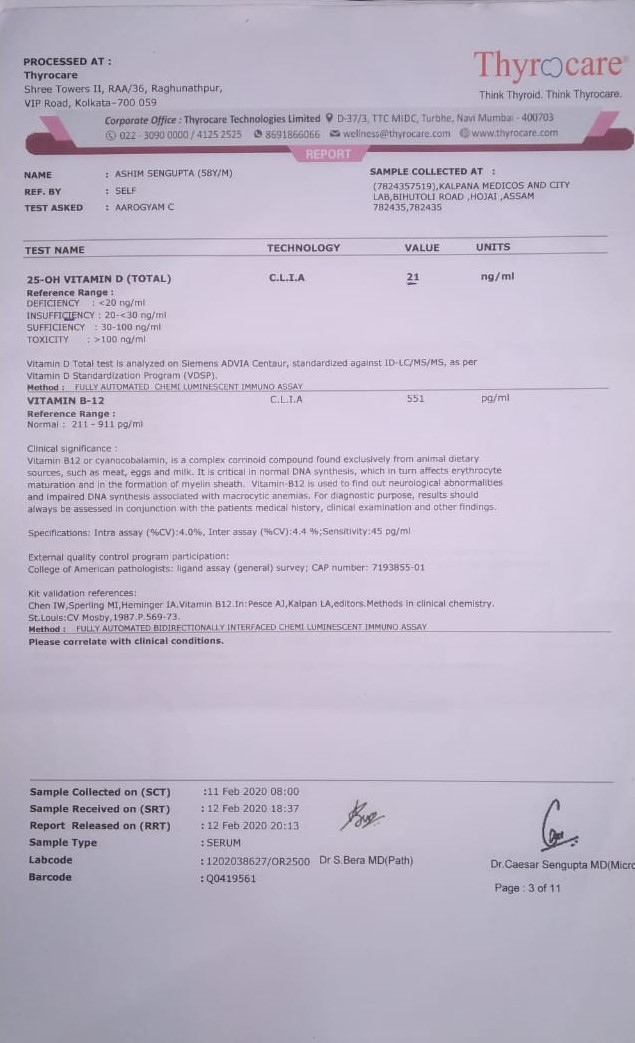

In [30]:
import cv2
import numpy as np
import os

# Load YOLO model
net = cv2.dnn.readNet('/content/yolov3.weights', '/content/yolov3-custom.cfg')

def get_output_layers(net):
    layer_names = net.getLayerNames()
    output_layers = []
    out_layers = net.getUnconnectedOutLayers()

    for i in out_layers:
        output_layers.append(layer_names[i - 1])  # Adjust for 1-based index

    return output_layers

# Specify the image path
image_path = r"/content/repo4.jpg"

# Check if the image path is valid
if os.path.exists(image_path):
    print("Image path is valid.")
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        print("Error: Could not read the image. Please check the file path.")
    else:
        # Prepare the image
        scale = 0.00392
        blob = cv2.dnn.blobFromImage(image, scale, (416, 416), (0, 0, 0), True, crop=False)
        net.setInput(blob)

        # Get output from the model
        outs = net.forward(get_output_layers(net))

        # Process the output as needed
        class_ids = []
        confidences = []
        boxes = []

        # Further processing of the outputs...
        for out in outs:
            for detection in out:
                scores = detection[5:]  # Assuming the first 5 are for x, y, w, h, confidence
                class_id = np.argmax(scores)  # Class with highest score
                confidence = scores[class_id]  # Get confidence score
                if confidence > 0.5:  # Threshold
                    # Get the bounding box coordinates
                    center_x = int(detection[0] * image.shape[1])
                    center_y = int(detection[1] * image.shape[0])
                    w = int(detection[2] * image.shape[1])
                    h = int(detection[3] * image.shape[0])

                    # Calculate top left corner
                    x = int(center_x - w / 2)
                    y = int(center_y - h / 2)

                    boxes.append([x, y, w, h])
                    confidences.append(float(confidence))
                    class_ids.append(class_id)

        # Define thresholds for NMS
        conf_threshold = 0.5  # Confidence threshold
        nms_threshold = 0.4    # NMS threshold

        # Apply Non-Maximum Suppression
        indices = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)

        # Draw boxes and labels on the image
        for i in indices:
            i = i[0]  # Get the index of the bounding box
            box = boxes[i]
            x, y, w, h = box
            label = str(classes[class_ids[i]])
            color = (0, 255, 0)  # Green color for bounding boxes
            cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
            cv2.putText(image, label, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Display the image (optional)
        cv2_imshow(image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()
else:
    print("Image path is invalid. Please check the path.")


In [31]:
#cropping detected objects and passing into tesseract OCR
A = []
for i in indices:
    i = i[0]
    box = boxes[i]
    x = box[0]
    y = box[1]
    w = box[2]
    h = box[3]
    crop_img = image[y:y+h, x:x+w]
    cv2.imwrite("Crop/crop__" + str(i) + ".jpg",crop_img)
    # grayscale region within bounding box
    gray = cv2.cvtColor(crop_img, cv2.COLOR_RGB2GRAY)
    # resize image to three times as large as original for better readability
    gray = cv2.resize(gray, None, fx = 3, fy = 3, interpolation = cv2.INTER_CUBIC)
    # perform gaussian blur to smoothen image
    blur = cv2.GaussianBlur(gray, (5,5), 0)
    # threshold the image using Otsus method to preprocess for tesseract
    ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU | cv2.THRESH_BINARY_INV)
    #perfrom bitwise not to flip image to black text on white background
    roi = cv2.bitwise_not(thresh)
    #saving the roi regions
    cv2.imwrite("Crop/roi__" + str(i) + ".jpg",roi)
    #passing to tesseract
    c = py.image_to_string(roi, config = '--oem 3')
    A.append(c)

In [32]:
#Splitting elements of A

B =[]
N = len(A)
for i in range(N):
    a = A[i].split('\n')
    B.append(a)

In [33]:
# Conv into dictionary

#declaring the dict key values
K = ["Test Name", "Unit", "Reference Value", "Value"]
Data = dict(zip(K,B))

In [34]:
#Creating a Dataframe
Y = pd.DataFrame(dict([ (k,pd.Series(v)) for k,v in Data.items() ]))


In [35]:
# Check the contents of the DataFrame Y
print(Y)  # This will show you the contents of Y

# If Y is empty, handle the situation accordingly
if Y.empty:
    print("The DataFrame Y is empty. Cannot export to CSV.")
else:
    # Exporting to CSV with the appropriate headers
    Y.to_csv(r'/content/cust_ocr.csv', index=False, header=['Test Name', 'Unit', 'Reference Value', 'Value'])


Empty DataFrame
Columns: []
Index: []
The DataFrame Y is empty. Cannot export to CSV.


In [36]:
import pandas as pd

# Example data
data = {
    'Test Name': ['Test 1', 'Test 2'],
    'Unit': ['Unit 1', 'Unit 2'],
    'Reference Value': [10, 20],
    'Value': [15, 25]
}

# Create DataFrame
Y = pd.DataFrame(data)
print(Y)


  Test Name    Unit  Reference Value  Value
0    Test 1  Unit 1               10     15
1    Test 2  Unit 2               20     25


In [37]:
# Assume Y is already defined
# Example of adding columns
Y['Test Name'] = ['Test 1', 'Test 2']  # Adding a new column
Y['Unit'] = ['Unit 1', 'Unit 2']        # Adding another column
Y['Reference Value'] = [10, 20]         # And another one
Y['Value'] = [15, 25]                    # And another one

print(Y)


  Test Name    Unit  Reference Value  Value
0    Test 1  Unit 1               10     15
1    Test 2  Unit 2               20     25


In [38]:
# New data to append
new_data = {
    'Test Name': ['Test 3'],
    'Unit': ['Unit 3'],
    'Reference Value': [30],
    'Value': [35]
}

# Convert new_data to a DataFrame
new_df = pd.DataFrame(new_data)

# Append new_df to Y
Y = pd.concat([Y, new_df], ignore_index=True)

print(Y)


  Test Name    Unit  Reference Value  Value
0    Test 1  Unit 1               10     15
1    Test 2  Unit 2               20     25
2    Test 3  Unit 3               30     35


In [39]:
Y = pd.read_csv(r'/content/cust_ocr.csv')
Y.head(5)

,Test Name,Unit,Reference Value,Value
0,TOTAL TRIIODOTHYRONINE (T3),Ing/dl,60-200,79.00
1,TOTAL THYROXINE (T4),sa/d!,4.5-12,5.10
2,THYROID STIMULATING HORMONE (TSH,IU/ml,0.3-5.5,3.09


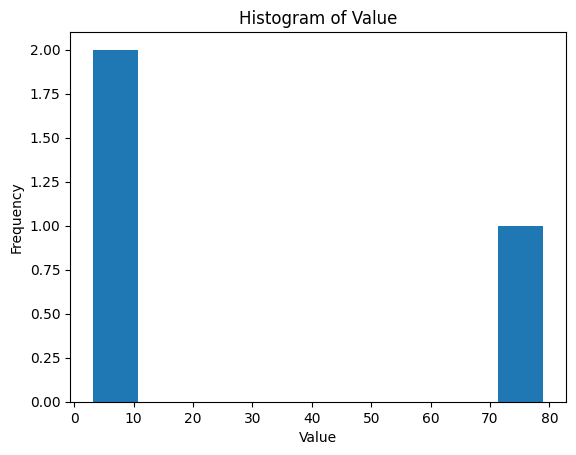

In [40]:
# prompt: Using dataframe Y: histogram

# Import the necessary library for plotting
import matplotlib.pyplot as plt

# Create a histogram of the 'Value' column
plt.hist(Y['Value'])

# Add labels and a title
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Value')

# Show the plot
plt.show()


In [41]:
#Exporting to CSV
Y.to_csv (r'/content/cust_ocr.csv', index = False, header=['Test Name', 'Unit', 'Reference Value', 'Value'])

In [42]:
!sudo apt-get install tesseract-ocr


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 0s (12.4 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debco

In [43]:
!pip install pytesseract
!pip install opencv-python
!pip install Pillow

import pytesseract as py
import cv2
from PIL import Image

# Load the image using OpenCV
img = cv2.imread('/content/crop__0.jpg')

# Convert the image from a NumPy array to a PIL Image object
img = Image.fromarray(img)

# Perform OCR using pytesseract
b = py.image_to_string(img,config='--oem 3')

In [44]:
# Load the image using OpenCV
img = cv2.imread('/content/crop__0.jpg')

ray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) #Use the original NumPy array 'img'
# resize image to three times as large as original for better readability
gray = cv2.resize(ray, None, fx = 3, fy = 3, interpolation = cv2.INTER_CUBIC) #Renamed 'ray' to 'gray'
# perform gaussian blur to smoothen image
blur = cv2.GaussianBlur(gray, (5,5), 0)
#cv2.imshow("Gray", gray)
#cv2.waitKey(0)
# threshold the image using Otsus method to preprocess for tesseract
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU | cv2.THRESH_BINARY_INV)
#cv2.imshow("Otsu Threshold", roi)
#cv2.waitKey(0)

# perfrom bitwise not to flip image to black text on white background
roi = cv2.bitwise_not(thresh)
# perform another blur on character region


text = py.image_to_string(roi, config='--oem 3')
print(text)

TOTAL TRIIODOTHYRONINE (T3)
TOTAL THYROXINE (T4)
THYROID STIMULATING HORMONE (TSH)

